> **Task 1.1 — Load and Explore**

---



In [ ]:
import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Download dataset
path = kagglehub.dataset_download("iroldan/real-doppler-raddar-database")

print("Dataset path:", path)


100%|██████████| 63.6M/63.6M [00:03<00:00, 20.8MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/iroldan/real-doppler-raddar-database/versions/2



```

AI assistance was used to help combine
multiple CSV files into one dataset.

```






In [ ]:
all_data = []

for label in ["Drones", "Cars", "People"]:

    for subfolder in os.listdir(path + "/" + label):

        folder_path = path + "/" + label + "/" + subfolder

        for file in os.listdir(folder_path):

            file_path = folder_path + "/" + file

            df = pd.read_csv(file_path, header=None)

            df["label"] = label

            all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

In [ ]:
print(final_df.head())
print(final_df.shape)
print(final_df.isnull().sum())
print(final_df["label"].value_counts())

        0       1       2       3       4       5       6       7       8  \
0 -116.76 -118.34 -127.55 -116.18 -116.98 -112.81 -110.41 -112.26 -116.38   
1 -113.02 -118.89 -119.19 -112.34 -114.65 -114.81 -114.70 -113.09 -114.95   
2 -112.93 -129.12 -120.33 -116.03 -117.70 -119.86 -117.79 -118.80 -119.37   
3 -113.45 -118.00 -134.02 -117.15 -114.18 -119.78 -117.57 -121.95 -121.73   
4 -110.84 -114.87 -115.55 -113.05 -114.12 -120.10 -123.04 -117.79 -116.43   

        9  ...      52      53      54      55      56      57      58  \
0 -124.00  ... -119.26 -125.01 -122.77 -131.87 -117.13 -125.12 -119.23   
1 -122.26  ... -116.95 -116.11 -111.43 -119.55 -116.79 -114.50 -121.90   
2 -127.55  ... -115.87 -115.60 -114.63 -120.12 -121.49 -117.34 -119.65   
3 -122.01  ... -120.02 -116.33 -126.20 -118.70 -120.77 -128.06 -122.15   
4 -123.65  ... -120.09 -114.53 -116.82 -137.06 -125.90 -122.79 -113.53   

       59      60   label  
0 -128.42 -121.94  Drones  
1 -122.81 -127.02  Drones  
2 -122.7



```

The dataset is relatively balanced,
but F1-score will still be used for evaluation.


```



> **Task 1.2 — Split the data**

In [ ]:
X = final_df.drop("label",axis=1)
y = final_df["label"]

label = LabelEncoder()
y = label.fit_transform(y)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.23,random_state=42,stratify=y)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred, zero_division=0, average="weighted")

print('F1 score: ',f1)

F1 score:  0.7052782335059475


> **Task 1.3 — Train and Compare Models**


 > Logistic Regression

---



In [ ]:

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train,y_train)

y_pred_log = log_model.predict(X_test)

acc_log = accuracy_score(y_test,y_pred_log)
prec_log = precision_score(y_test,y_pred_log,average="weighted")
rec_log = recall_score(y_test,y_pred_log,average="weighted")
f1_log = f1_score(y_test,y_pred_log,average="weighted")

print("Logistic Regression Results:",acc_log,prec_log,rec_log,f1_log)



Logistic Regression Results: 0.5703015507030155 0.5689422199225767 0.5703015507030155 0.5682387206437077


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


> Random Forest

---




In [ ]:
rf_model = RandomForestClassifier(n_estimators=50,max_depth=10)
rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test,y_pred_rf)
prec_rf = precision_score(y_test,y_pred_rf,average="weighted")
rec_rf = recall_score(y_test,y_pred_rf,average="weighted")
f1_rf = f1_score(y_test,y_pred_rf,average="weighted")

print("Random Forest Results:",acc_rf,prec_rf,rec_rf,f1_rf)

Random Forest Results: 0.7479090374790903 0.7729722653813889 0.7479090374790903 0.7509535360744494


> KNN

---



In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=20)
knn_model.fit(X_train,y_train)

y_pred_knn = knn_model.predict(X_test)

acc_knn = accuracy_score(y_test,y_pred_knn)
prec_knn = precision_score(y_test,y_pred_knn,average="weighted")
rec_knn = recall_score(y_test,y_pred_knn,average="weighted")
f1_knn = f1_score(y_test,y_pred_knn,average="weighted")

print("KNN Results:",acc_knn,prec_knn,rec_knn,f1_knn)



> KNN Hyperparameter Tuning


---



In [ ]:

k_values = [11,15,18,20]
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((k, acc))

results

best_k, best_acc = max(results,key=lambda x: x[1])

print("Best K:", best_k)
print("Best accuracy:",round(float(best_acc), 3))

Best K: 20
Best accuracy: 0.761


> Decision Tree

---



In [ ]:
dt_model = DecisionTreeClassifier(max_depth=25)
dt_model.fit(X_train,y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test,y_pred_dt)
prec_dt = precision_score(y_test,y_pred_dt,average="weighted")
rec_dt = recall_score(y_test,y_pred_dt,average="weighted")
f1_dt = f1_score(y_test,y_pred_dt,average="weighted")

print("Decision Tree Results:",acc_dt,prec_dt,rec_dt,f1_dt)


Decision Tree Results: 0.746846602468466 0.7687047828478712 0.746846602468466 0.7466655069877846


> Decision Tree Hyperparameter Tuning


---



In [ ]:

print("Decision Tree Tuning:")

depths = [20,25,30,40]

for d in depths:

    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print("Depth:", d,"Accuracy:",accuracy_score(y_test,pred))

Decision Tree Tuning:
Depth: 20 Accuracy: 0.7466657624666576
Depth: 25 Accuracy: 0.7456937474569375
Depth: 30 Accuracy: 0.7456937474569375
Depth: 40 Accuracy: 0.7379402323794023


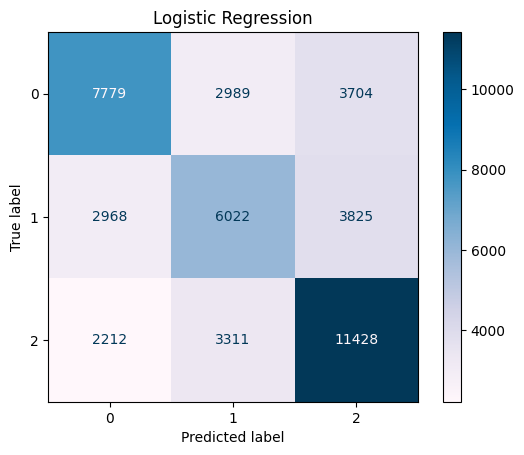

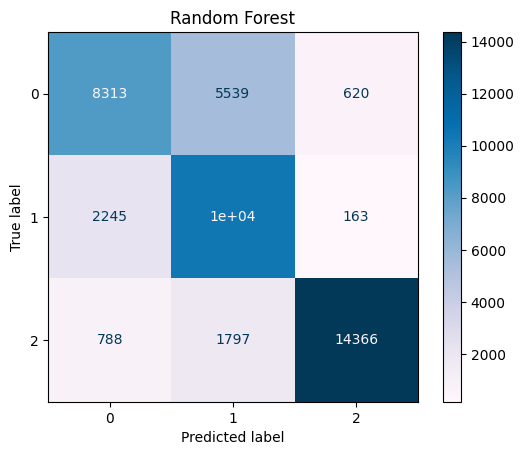

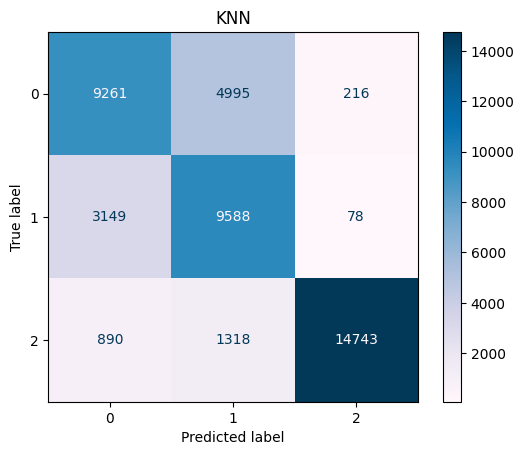

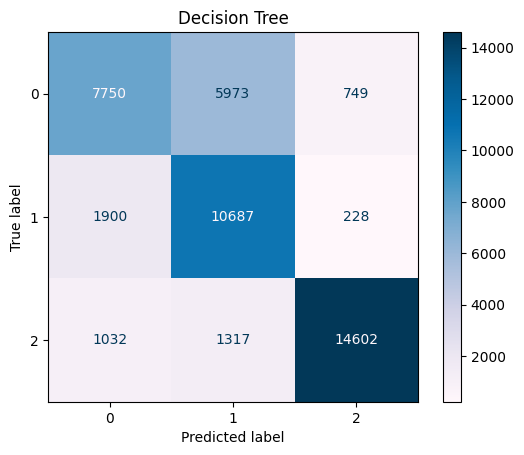

In [ ]:
cm_log = confusion_matrix(y_test,y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot(cmap="PuBu")
plt.title("Logistic Regression")
plt.show()


cm_rf = confusion_matrix(y_test,y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="PuBu")
plt.title("Random Forest")
plt.show()


cm_knn = confusion_matrix(y_test,y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot(cmap="PuBu")
plt.title("KNN")
plt.show()


cm_dt = confusion_matrix(y_test,y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot(cmap="PuBu")
plt.title("Decision Tree")
plt.show()

> KNN was the best model because it achieved the highest performance with fewer prediction errors.


> **Task 2.1: Build and Train**


> Neural Network
---



In [ ]:

import tensorflow as tf

print(tf.__version__)


2.20.0


In [ ]:

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_pred_nn = nn_model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn, axis=1)

nn_model = Sequential([
    Dense(128, activation="relu", input_shape=(61,)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")])
9

nn_model.compile(optimizer="adam",loss="sparse_categorical_crossentropy", metrics=["accuracy"])


early_stop = EarlyStopping(monitor="val_loss",patience=7,restore_best_weights=True)


history = nn_model.fit(X_train_scaled,y_train,validation_split=0.2,epochs=100,batch_size=32,callbacks=[early_stop])

1383/1383 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3703/3703 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7268 - loss: 0.5902 - val_accuracy: 0.7646 - val_loss: 0.5080
Epoch 2/100
3703/3703 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7591 - loss: 0.5204 - val_accuracy: 0.7729 - val_loss: 0.4896
Epoch 3/100
3703/3703 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7664 - loss: 0.5022 - val_accuracy: 0.7777 - val_loss: 0.4787
Epoch 4/100
3703/3703 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7713 - loss: 0.4910 - val_accuracy: 0.7718 - val_loss: 0.4848
Epoch 5/100
3703/3703 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7749 - loss: 0.4817 - val_accuracy: 0.7780 - val_loss: 0.4728
Epoch 6/100
3703/3703 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7774 - loss: 0.4763 - val_accuracy: 0.7810 - val_loss: 0.4606
Epoch 7/100
3703/3703 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7803 - loss: 0.4681 - val_accuracy: 0.7817 - val_loss: 0.4617
Epoch 8/100
3703/3703 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7804 - loss: 0.4653 - va

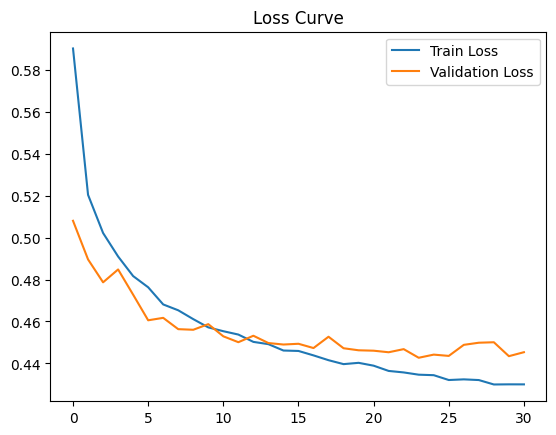

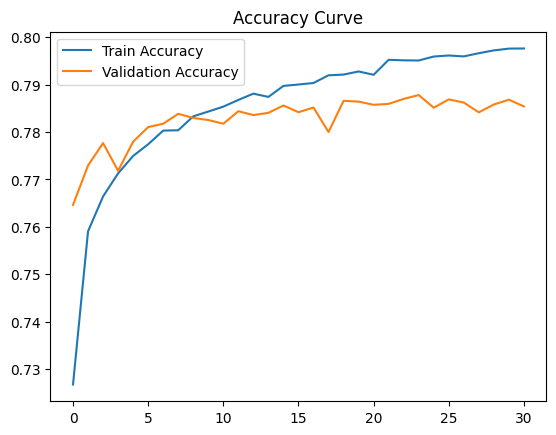

In [ ]:

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Loss Curve")

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()


plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")

plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.show()

> **Task 2.2 - Compare with Step 1**

In [ ]:
acc_nn = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test,y_pred_nn,average="weighted")
rec_nn = recall_score(y_test,y_pred_nn,average="weighted")
f1_nn = f1_score(y_test,y_pred_nn,average="weighted")

In [ ]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","KNN","Decision Tree","Neural Network"],
    "Accuracy":[acc_log,acc_rf,acc_knn,acc_dt,acc_nn],
    "Precision":[prec_log,prec_rf,prec_knn,prec_dt,prec_nn],
    "Recall":[rec_log,rec_rf,rec_knn,rec_dt,rec_nn],
    "F1-Score":[f1_log,f1_rf,f1_knn,f1_dt,f1_nn]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.570302   0.568942  0.570302  0.568239
1        Random Forest  0.747909   0.772972  0.747909  0.750954
2                  KNN  0.759347   0.778151  0.759347  0.764831
3        Decision Tree  0.746847   0.768705  0.746847  0.746666
4       Neural Network  0.789299   0.802774  0.789299  0.790671


1383/1383 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step


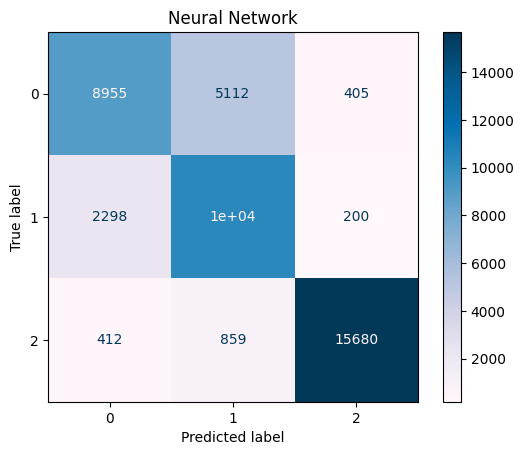

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

y_pred_nn = nn_model.predict(X_test_scaled)

y_pred_nn = np.argmax(y_pred_nn, axis=1)

cm_nn = confusion_matrix(y_test, y_pred_nn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn)

disp.plot(cmap="PuBu")

plt.title("Neural Network")

plt.show()

> neural network was the best of all the models because it gives the highest accuracy and F1 score
It was able to classify radar signals more accurately than the other models    